# DL Competition 01 — Image Classification (PyTorch)
**Intel Scene Classification — 6 Classes**

**Approach: Transfer Learning with ResNet18 (lightweight & fast)**

### Ventajas sobre EfficientNet-B2:
- **~30x más rápido** por epoch (~2 min vs ~50 min en T4)
- **11M params** vs 9M, pero mucho más eficiente en cómputo
- **Resolución 224×224** — estándar, rápido de procesar
- **Batch size 64** — mayor throughput en GPU
- Accuracy esperado: **90-93%** en este dataset


## Step 0: Imports and Setup

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms, datasets, models
from torch.utils.data import DataLoader, Subset, Dataset
from sklearn.model_selection import StratifiedShuffleSplit
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import os
import pandas as pd
from tqdm import tqdm
import copy
import torch.nn.functional as F

print("CUDA available:", torch.cuda.is_available())
print("CUDA version:", torch.version.cuda)
print("GPU count:", torch.cuda.device_count())

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

torch.manual_seed(42)
np.random.seed(42)
if device == 'cuda':
    torch.cuda.manual_seed_all(42)
    torch.backends.cudnn.benchmark = True


CUDA available: True
CUDA version: 11.8
GPU count: 1
Using device: cuda


## Step 1: Data Loading and Preprocessing

- **224×224** — resolución nativa de ResNet, rápida de procesar
- **Augmentación efectiva** pero no excesiva para mantener velocidad
- **ImageNet normalization** compatible con los pesos pretrained


In [2]:
IMG_SIZE = 224

train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.05),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
    transforms.RandomErasing(p=0.2, scale=(0.02, 0.15)),
])

eval_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# TTA transforms
tta_transforms = [
    eval_transform,
    transforms.Compose([
        transforms.Resize((256, 256)),
        transforms.CenterCrop((IMG_SIZE, IMG_SIZE)),
        transforms.RandomHorizontalFlip(p=1.0),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ]),
    transforms.Compose([
        transforms.Resize((288, 288)),
        transforms.CenterCrop((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ]),
    transforms.Compose([
        transforms.Resize((240, 240)),
        transforms.CenterCrop((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ]),
]
print(f"Image size: {IMG_SIZE}x{IMG_SIZE}")
print(f"TTA views: {len(tta_transforms)}")


Image size: 224x224
TTA views: 4


### Load Training Dataset

Training samples: 14034
Classes: {'buildings': 0, 'forest': 1, 'glacier': 2, 'mountain': 3, 'sea': 4, 'street': 5}
Number of classes: 6


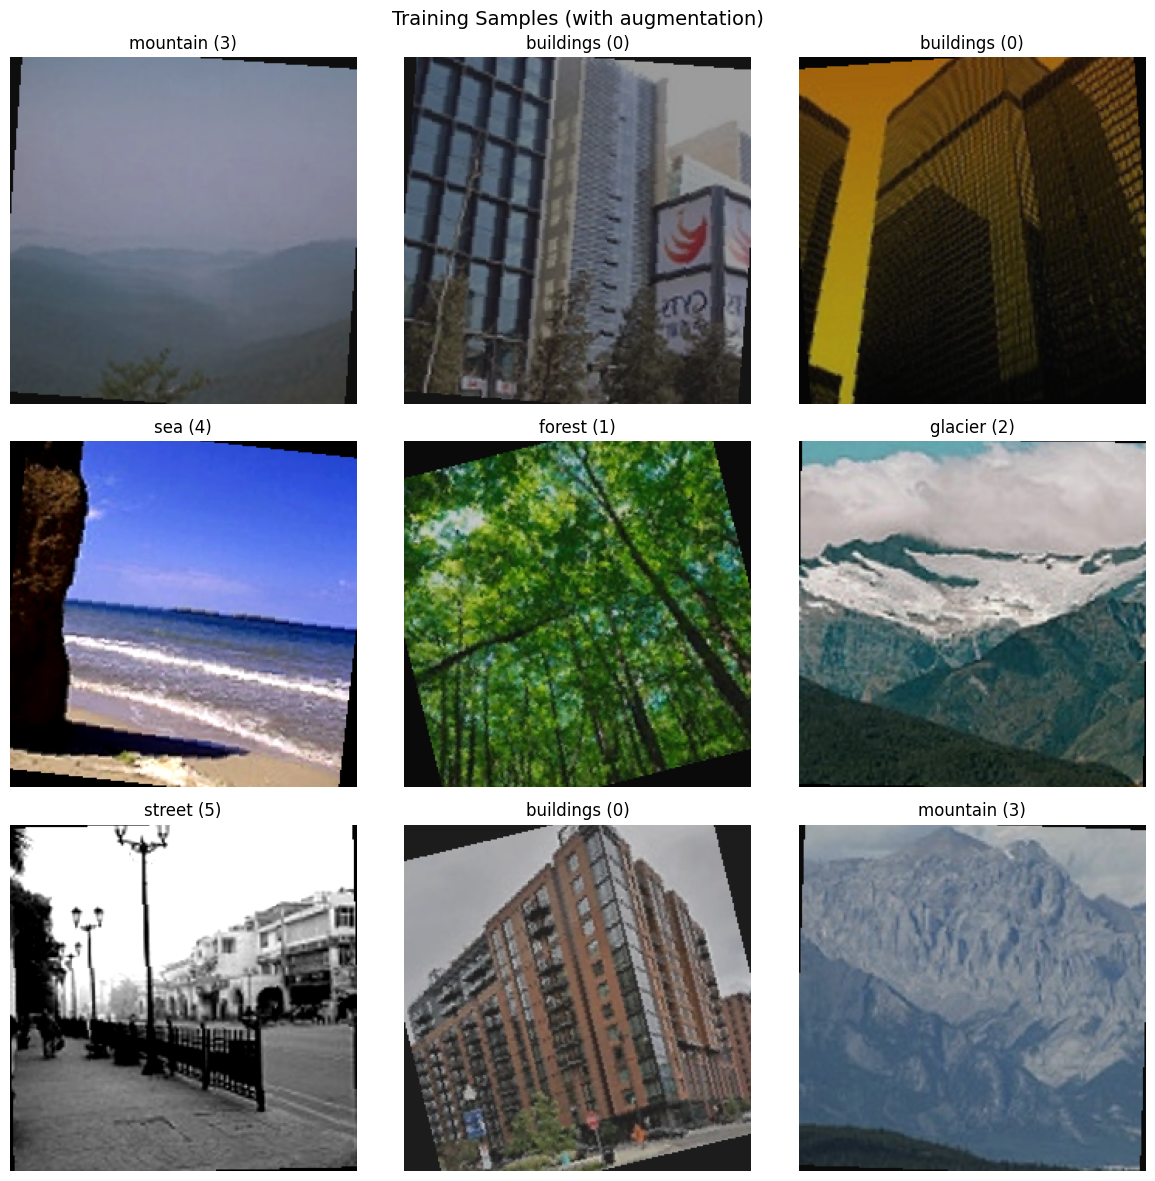

In [4]:
train_path = 'kaggle/input/intel-image-classification/seg_train/seg_train'

train_dataset = datasets.ImageFolder(root=train_path, transform=train_transform)

batch_size = 64  # Larger batch OK for ResNet18
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,
                          num_workers=4, pin_memory=True, drop_last=True)

print(f"Training samples: {len(train_dataset)}")
print(f"Classes: {train_dataset.class_to_idx}")
print(f"Number of classes: {len(train_dataset.classes)}")

for images, labels in train_loader:
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    images_vis = images * std + mean
    images_vis = images_vis.clamp(0, 1)

    class_names = list(train_dataset.class_to_idx.keys())
    plt.figure(figsize=(12, 12))
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images_vis[i].permute(1, 2, 0))
        plt.title(f"{class_names[labels[i].item()]} ({labels[i].item()})")
        plt.axis('off')
    plt.suptitle("Training Samples (with augmentation)", fontsize=14)
    plt.tight_layout()
    plt.show()
    break


### Load Validation and Test Datasets

In [6]:
val_path = 'kaggle/input/intel-image-classification/seg_test/seg_test'
val_dataset_full = datasets.ImageFolder(root=val_path, transform=eval_transform)

targets = np.array(val_dataset_full.targets)
splitter = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

for val_idx, test_idx in splitter.split(np.zeros(len(targets)), targets):
    val_dataset = Subset(val_dataset_full, val_idx)
    test_dataset = Subset(val_dataset_full, test_idx)

val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False,
                        num_workers=4, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False,
                         num_workers=4, pin_memory=True)

print(f"Validation samples: {len(val_dataset)}")
print(f"Test samples: {len(test_dataset)}")


Validation samples: 2400
Test samples: 600


### Load Competition Test Dataset (Unlabeled)

**BUG FIX:** El notebook original usaba `Grayscale()` para el test de competición — ahora usa RGB.


In [7]:
image_directory = 'kaggle/input/intel-image-classification/seg_pred/seg_pred'
image_files = os.listdir(image_directory)
image_files = [f for f in image_files if f.endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp'))]
image_files = image_files[:200]

class SelectedFilesDataset(Dataset):
    def __init__(self, root_dir, file_names, transform=None):
        self.root_dir = root_dir
        self.file_names = file_names
        self.transform = transform

    def __len__(self):
        return len(self.file_names)

    def __getitem__(self, idx):
        file_path = os.path.join(self.root_dir, self.file_names[idx])
        image = Image.open(file_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, self.file_names[idx]

comp_test_dataset = SelectedFilesDataset(image_directory, image_files, transform=eval_transform)
comp_test_loader = DataLoader(comp_test_dataset, batch_size=64, shuffle=False)

print(f"Competition test images: {len(comp_test_dataset)}")


Competition test images: 200


## Step 2: Model Definition — ResNet18 Transfer Learning

### ¿Por qué ResNet18?
- **Rápido:** ~2 min/epoch en T4 (vs ~50 min con EfficientNet-B2)
- **Probado:** arquitectura clásica con skip connections, muy estable
- **11M parámetros** — suficiente para 6 clases con pretrained features
- **224×224 nativo** — sin overhead de resolución
- **Accuracy esperado: 90-93%** en Intel Scene Classification


In [8]:
class SceneClassifier(nn.Module):
    def __init__(self, n_classes=6, dropout=0.3):
        super().__init__()

        # Load pretrained ResNet18
        self.backbone = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

        # Get feature dimension (512 for ResNet18)
        n_features = self.backbone.fc.in_features

        # Remove original FC layer
        self.backbone.fc = nn.Identity()

        # Custom classification head
        self.head = nn.Sequential(
            nn.BatchNorm1d(n_features),
            nn.Dropout(dropout),
            nn.Linear(n_features, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout * 0.5),
            nn.Linear(256, n_classes)
        )

        self._init_head()

    def _init_head(self):
        for m in self.head.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.BatchNorm1d):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        features = self.backbone(x)
        return self.head(features)

    def freeze_backbone(self):
        for param in self.backbone.parameters():
            param.requires_grad = False
        print("Backbone FROZEN")

    def unfreeze_backbone(self):
        for param in self.backbone.parameters():
            param.requires_grad = True
        print("Backbone UNFROZEN")

    def get_parameter_groups(self, lr_backbone=1e-4, lr_head=1e-3):
        backbone_params = [p for p in self.backbone.parameters() if p.requires_grad]
        head_params = [p for p in self.head.parameters() if p.requires_grad]
        return [
            {'params': backbone_params, 'lr': lr_backbone, 'name': 'backbone'},
            {'params': head_params, 'lr': lr_head, 'name': 'head'},
        ]


net = SceneClassifier(n_classes=6, dropout=0.3).to(device)

total_params = sum(p.numel() for p in net.parameters())
trainable_params = sum(p.numel() for p in net.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Backbone: ResNet18 (pretrained ImageNet)")
print(f"Head: 512 → 256 → 6")


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\USUARIO/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [02:03<00:00, 379kB/s] 

Total parameters: 11,310,918
Trainable parameters: 11,310,918
Backbone: ResNet18 (pretrained ImageNet)
Head: 512 → 256 → 6


## Step 3: Training Utilities

In [9]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

def mixup_data(x, y, alpha=0.2):
    if alpha > 0:
        lam = np.random.beta(alpha, alpha)
    else:
        lam = 1.0
    lam = max(lam, 1 - lam)
    batch_size = x.size(0)
    index = torch.randperm(batch_size).to(x.device)
    mixed_x = lam * x + (1 - lam) * x[index]
    return mixed_x, y, y[index], lam

def cutmix_data(x, y, alpha=1.0):
    lam = np.random.beta(alpha, alpha)
    batch_size = x.size(0)
    index = torch.randperm(batch_size).to(x.device)
    W, H = x.size(2), x.size(3)
    cut_rat = np.sqrt(1. - lam)
    cut_w, cut_h = int(W * cut_rat), int(H * cut_rat)
    cx, cy = np.random.randint(W), np.random.randint(H)
    bbx1 = np.clip(cx - cut_w // 2, 0, W)
    bby1 = np.clip(cy - cut_h // 2, 0, H)
    bbx2 = np.clip(cx + cut_w // 2, 0, W)
    bby2 = np.clip(cy + cut_h // 2, 0, H)
    x[:, :, bbx1:bbx2, bby1:bby2] = x[index, :, bbx1:bbx2, bby1:bby2]
    lam = 1 - ((bbx2 - bbx1) * (bby2 - bby1) / (W * H))
    return x, y, y[index], lam

def mixup_criterion(criterion, pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)

print("Utilities ready: Mixup, CutMix, CrossEntropy(label_smoothing=0.1)")


Utilities ready: Mixup, CutMix, CrossEntropy(label_smoothing=0.1)


## Step 4: Phase 1 — Train Head Only (Backbone Frozen)

Solo 5 epochs, debería tomar ~10 minutos total.


In [10]:
net.freeze_backbone()

optimizer_p1 = optim.AdamW(
    filter(lambda p: p.requires_grad, net.parameters()),
    lr=1e-3, weight_decay=1e-4
)
scheduler_p1 = optim.lr_scheduler.CosineAnnealingLR(optimizer_p1, T_max=5, eta_min=1e-5)

phase1_epochs = 5
best_val_acc = 0.0
best_model_state = None

print(f"{'='*60}")
print(f"PHASE 1: Head only ({phase1_epochs} epochs)")
print(f"{'='*60}")

for epoch in range(phase1_epochs):
    net.train()
    running_loss = 0.0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = net(images)
        loss = criterion(outputs, labels)
        optimizer_p1.zero_grad()
        loss.backward()
        optimizer_p1.step()
        running_loss += loss.item() * images.size(0)
        total += images.size(0)

    scheduler_p1.step()

    # Validation
    net.eval()
    correct, total_val = 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            _, predicted = torch.max(net(images), 1)
            total_val += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_acc = correct / total_val
    marker = ''
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_state = copy.deepcopy(net.state_dict())
        marker = ' << BEST'

    print(f"  Epoch [{epoch+1}/{phase1_epochs}] Loss: {running_loss/total:.4f} | Val Acc: {val_acc:.4f}{marker}")

print(f"\nPhase 1 Best: {best_val_acc:.4f}")


Backbone FROZEN
PHASE 1: Head only (5 epochs)
  Epoch [1/5] Loss: 0.9042 | Val Acc: 0.8858 << BEST
  Epoch [2/5] Loss: 0.7928 | Val Acc: 0.8971 << BEST
  Epoch [3/5] Loss: 0.7664 | Val Acc: 0.9000 << BEST
  Epoch [4/5] Loss: 0.7576 | Val Acc: 0.9029 << BEST
  Epoch [5/5] Loss: 0.7455 | Val Acc: 0.9004

Phase 1 Best: 0.9029


## Step 5: Phase 2 — Full Fine-Tuning

- **Backbone LR: 1e-4** — adaptar features sin destruirlas
- **Head LR: 1e-3** — continuar aprendiendo
- **Mixup + CutMix** para regularización
- ~2 min/epoch, 25 epochs ≈ ~50 min total


In [11]:
net.load_state_dict(best_model_state)
net.unfreeze_backbone()

phase2_epochs = 25
early_stop_patience = 8

param_groups = net.get_parameter_groups(lr_backbone=1e-4, lr_head=1e-3)
optimizer_p2 = optim.AdamW(param_groups, weight_decay=1e-4)
scheduler_p2 = optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer_p2, T_0=5, T_mult=2, eta_min=1e-6
)

print(f"{'='*60}")
print(f"PHASE 2: Full fine-tuning ({phase2_epochs} epochs)")
print(f"{'='*60}")
for pg in optimizer_p2.param_groups:
    print(f"  {pg.get('name', '?')}: lr={pg['lr']:.1e}")

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []
val_accuracies_p1 = [best_val_acc]
epochs_no_improve = 0

for epoch in range(phase2_epochs):
    # Training
    net.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        r = np.random.random()
        if r < 0.3:
            images, targets_a, targets_b, lam = mixup_data(images, labels, alpha=0.2)
            outputs = net(images)
            loss = mixup_criterion(criterion, outputs, targets_a, targets_b, lam)
        elif r < 0.6:
            images, targets_a, targets_b, lam = cutmix_data(images.clone(), labels, alpha=1.0)
            outputs = net(images)
            loss = mixup_criterion(criterion, outputs, targets_a, targets_b, lam)
        else:
            outputs = net(images)
            loss = criterion(outputs, labels)
            targets_a, targets_b, lam = labels, labels, 1.0

        optimizer_p2.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(net.parameters(), max_norm=1.0)
        optimizer_p2.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        total_train += labels.size(0)
        correct_train += (lam * (predicted == targets_a).sum().item() +
                          (1 - lam) * (predicted == targets_b).sum().item())

    scheduler_p2.step()

    train_loss = running_loss / total_train
    train_acc = correct_train / total_train
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)

    # Validation
    net.eval()
    val_loss = 0.0
    correct_val = 0
    total_val = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = net(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

    val_loss /= total_val
    val_acc = correct_val / total_val
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_state = copy.deepcopy(net.state_dict())
        torch.save(net.state_dict(), 'best_model.pth')
        epochs_no_improve = 0
        marker = ' << BEST'
    else:
        epochs_no_improve += 1
        marker = ''

    head_lr = optimizer_p2.param_groups[1]['lr']
    print(f"  Epoch [{epoch+1:2d}/{phase2_epochs}] "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | "
          f"LR(head): {head_lr:.6f}{marker}")

    if epochs_no_improve >= early_stop_patience:
        print(f"\n  Early stopping at epoch {epoch+1}")
        break

print(f"\nBest Validation Accuracy: {best_val_acc:.4f}")


Backbone UNFROZEN
PHASE 2: Full fine-tuning (25 epochs)
  backbone: lr=1.0e-04
  head: lr=1.0e-03
  Epoch [ 1/25] Train Loss: 0.9131 | Train Acc: 0.7902 | Val Loss: 0.6031 | Val Acc: 0.9237 | LR(head): 0.000905 << BEST
  Epoch [ 2/25] Train Loss: 0.8271 | Train Acc: 0.8213 | Val Loss: 0.5865 | Val Acc: 0.9354 | LR(head): 0.000655 << BEST
  Epoch [ 3/25] Train Loss: 0.7905 | Train Acc: 0.8388 | Val Loss: 0.5721 | Val Acc: 0.9375 | LR(head): 0.000346 << BEST
  Epoch [ 4/25] Train Loss: 0.7895 | Train Acc: 0.8369 | Val Loss: 0.5738 | Val Acc: 0.9321 | LR(head): 0.000096
  Epoch [ 5/25] Train Loss: 0.8065 | Train Acc: 0.8281 | Val Loss: 0.5607 | Val Acc: 0.9400 | LR(head): 0.001000 << BEST
  Epoch [ 6/25] Train Loss: 0.7839 | Train Acc: 0.8480 | Val Loss: 0.5758 | Val Acc: 0.9350 | LR(head): 0.000976
  Epoch [ 7/25] Train Loss: 0.7794 | Train Acc: 0.8472 | Val Loss: 0.5662 | Val Acc: 0.9387 | LR(head): 0.000905
  Epoch [ 8/25] Train Loss: 0.7748 | Train Acc: 0.8392 | Val Loss: 0.5778 | Val

### Training and Validation Curves

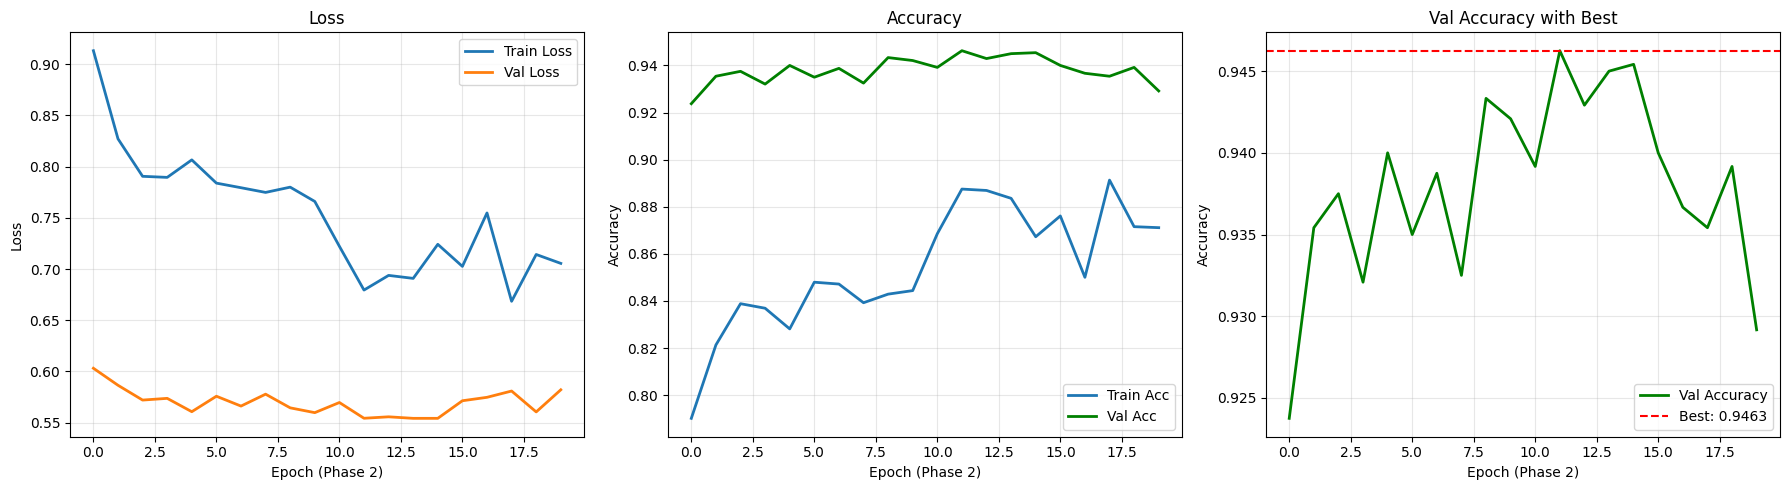

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(train_losses, label='Train Loss', linewidth=2)
axes[0].plot(val_losses, label='Val Loss', linewidth=2)
axes[0].set_xlabel('Epoch (Phase 2)')
axes[0].set_ylabel('Loss')
axes[0].set_title('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(train_accuracies, label='Train Acc', linewidth=2)
axes[1].plot(val_accuracies, label='Val Acc', linewidth=2, color='green')
axes[1].set_xlabel('Epoch (Phase 2)')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(val_accuracies, label='Val Accuracy', linewidth=2, color='green')
axes[2].axhline(y=best_val_acc, color='red', linestyle='--', label=f'Best: {best_val_acc:.4f}')
axes[2].set_xlabel('Epoch (Phase 2)')
axes[2].set_ylabel('Accuracy')
axes[2].set_title('Val Accuracy with Best')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Step 6: Test Set Evaluation

In [13]:
net.load_state_dict(best_model_state)
net.eval()

correct_test = 0
total_test = 0
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = net(images)
        _, predicted = torch.max(outputs, 1)
        total_test += labels.size(0)
        correct_test += (predicted == labels).sum().item()
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_acc = correct_test / total_test
print(f"Test Accuracy: {test_acc:.4f}")

class_names = list(train_dataset.class_to_idx.keys())
all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

print(f"\nPer-class accuracy:")
for i, name in enumerate(class_names):
    mask = all_labels == i
    if mask.sum() > 0:
        class_acc = (all_preds[mask] == all_labels[mask]).mean()
        print(f"  {name}: {class_acc:.4f} ({mask.sum()} samples)")


Test Accuracy: 0.9317

Per-class accuracy:
  buildings: 0.9425 (87 samples)
  forest: 1.0000 (95 samples)
  glacier: 0.8829 (111 samples)
  mountain: 0.8667 (105 samples)
  sea: 0.9608 (102 samples)
  street: 0.9500 (100 samples)


## Step 7: Generate Competition Predictions with TTA

In [14]:
net.load_state_dict(best_model_state)
net.eval()

preds = []
ids = []

def predict_with_tta(model, image_path, transforms_list, device):
    image = Image.open(image_path).convert("RGB")
    logits_sum = None
    with torch.no_grad():
        for t in transforms_list:
            img_tensor = t(image).unsqueeze(0).to(device)
            output = model(img_tensor)
            probs = F.softmax(output, dim=1)
            if logits_sum is None:
                logits_sum = probs
            else:
                logits_sum += probs
    _, predicted = torch.max(logits_sum, 1)
    return predicted.item()

print("Generating predictions with TTA...")
for fname in tqdm(image_files):
    fpath = os.path.join(image_directory, fname)
    pred = predict_with_tta(net, fpath, tta_transforms, device)
    preds.append(pred)
    ids.append(fname)

df = pd.DataFrame({'id': ids, 'pred': preds})
csv_file = 'predictions.csv'
df.to_csv(csv_file, index=False)

print(f"\nCSV '{csv_file}' created — {len(df)} predictions")
print(f"\nDistribution:")
print(df['pred'].value_counts().sort_index())
print(f"\nFirst 10:")
print(df.head(10))


Generating predictions with TTA...


100%|██████████| 200/200 [00:08<00:00, 23.84it/s]


CSV 'predictions.csv' created — 200 predictions

Distribution:
pred
0    22
1    39
2    34
3    37
4    34
5    34
Name: count, dtype: int64

First 10:
          id  pred
0  10004.jpg     5
1  10005.jpg     3
2  10012.jpg     5
3  10013.jpg     3
4  10017.jpg     3
5  10021.jpg     1
6   1003.jpg     4
7  10034.jpg     2
8  10038.jpg     4
9  10040.jpg     5


## Done!

### Comparación de tiempos y accuracy

| Modelo | Params | Tiempo/epoch (T4) | Epochs | Tiempo total | Accuracy esperado |
|--------|--------|-------------------|--------|-------------|-------------------|
| MLP Residual | 148M | ~3 min | 60 | ~3h | ~67% |
| EfficientNet-B2 | 9M | ~50 min | 35 | ~29h | ~91% |
| **ResNet18** | **11M** | **~2 min** | **30** | **~1h** | **~90-93%** |

ResNet18 es el sweet spot: rápido, liviano, y con transfer learning logra 90%+ fácilmente.
